01. Load Data

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/SMS Spam Collection Dataset.csv', 
                 encoding='latin-1')

# Cek kolom apa saja yang ada
print("Kolom:", df.columns.tolist())
print("\nShape:", df.shape)
print("\nSample data:")
print(df.head(5))

Kolom: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Shape: (5572, 5)

Sample data:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


02. Cleaning

In [2]:
# Ambil hanya kolom yang dibutuhkan dan rename
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

# Verifikasi
print("Shape:", df.shape)
print("\nSample data:")
print(df.head(10))
print("\nMissing values:")
print(df.isnull().sum())

Shape: (5572, 2)

Sample data:
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
5  spam  FreeMsg Hey there darling it's been 3 week's n...
6   ham  Even my brother is not like to speak with me. ...
7   ham  As per your request 'Melle Melle (Oru Minnamin...
8  spam  WINNER!! As a valued network customer you have...
9  spam  Had your mobile 11 months or more? U R entitle...

Missing values:
label    0
text     0
dtype: int64


03. Distribution Class

Distribusi label:
label
ham     4825
spam     747
Name: count, dtype: int64

Persentase:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


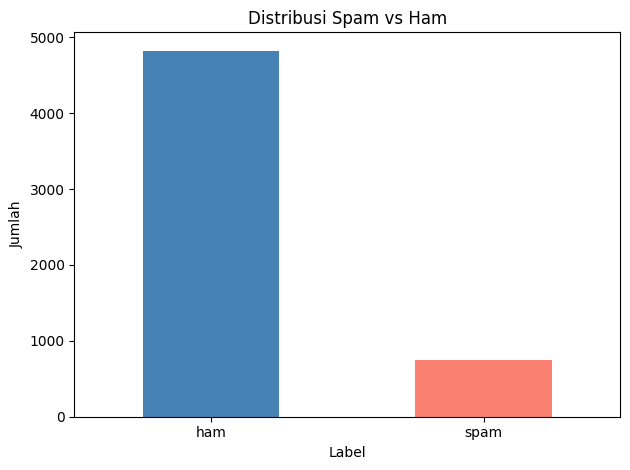

In [3]:
import matplotlib.pyplot as plt

# Hitung distribusi
print("Distribusi label:")
print(df['label'].value_counts())
print("\nPersentase:")
print(df['label'].value_counts(normalize=True).mul(100).round(2))

# Visualisasi
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribusi Spam vs Ham')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

04. Long Text Analysis

        count    mean    std   min    25%    50%    75%    max
label                                                         
ham    4825.0   71.02  58.02   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.87  29.18  13.0  132.5  149.0  157.0  224.0


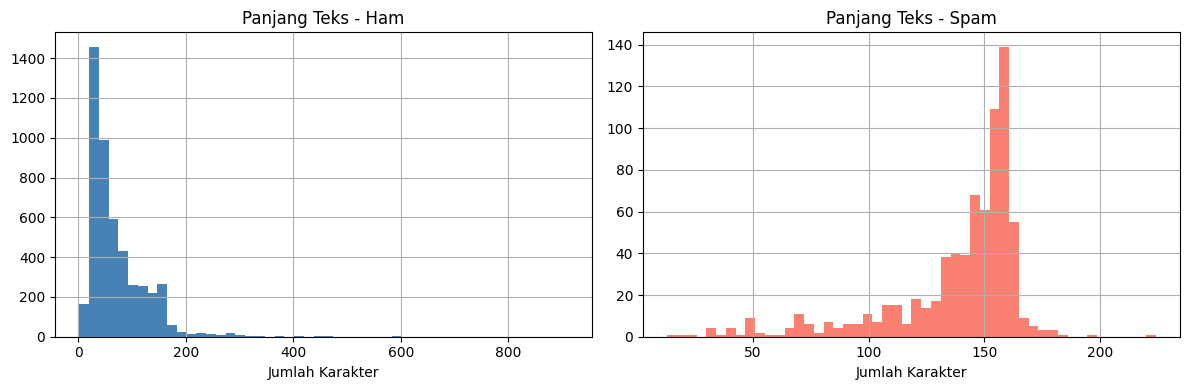

In [4]:
# Tambah kolom panjang teks
df['text_length'] = df['text'].apply(len)

# Statistik per label
print(df.groupby('label')['text_length'].describe().round(2))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['label'] == 'ham']['text_length'].hist(ax=axes[0], bins=50, color='steelblue')
axes[0].set_title('Panjang Teks - Ham')
axes[0].set_xlabel('Jumlah Karakter')

df[df['label'] == 'spam']['text_length'].hist(ax=axes[1], bins=50, color='salmon')
axes[1].set_title('Panjang Teks - Spam')
axes[1].set_xlabel('Jumlah Karakter')

plt.tight_layout()
plt.show()

05. Example 

In [5]:
print("=== Contoh SPAM ===")
for text in df[df['label'] == 'spam']['text'].head(5).values:
    print(f"- {text}\n")

print("=== Contoh HAM ===")
for text in df[df['label'] == 'ham']['text'].head(5).values:
    print(f"- {text}\n")

=== Contoh SPAM ===
- Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

- FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv

- WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.

- Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030

- SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info

=== Contoh HAM ===
- Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

- Ok lar... Joking wif u oni...

- U dun say so early hor... U c already th